# April 2026 batch — Global overview

This notebook is a first **visual** pass on the April 2026 fMRI batch: ten global-aggregate correlation matrices ($2\ \text{contrasts} \times 5\ \text{processing variants}$), plus a per-patient sample for sanity-checking subject-level heterogeneity.

Each matrix is a **signed Pearson correlation** $C_{ij} \in [-1, 1]$ over $N = 100$ ROIs from the **Schaefer 2018, 100-parcel × 17-network** atlas. ROI time series have length $T$ that depends on the processing variant ($T = 442$ for `bpfBOLD`/`bpfVASO`, $T = 597$ for the `optcom_*`/`MIRNoise_bold` family), giving a per-variant aspect ratio

$$
\gamma \;=\; \frac{N}{T} \;\in\; \left\{ \tfrac{100}{442} \approx 0.226,\ \tfrac{100}{597} \approx 0.168 \right\}
$$

used downstream for the Marchenko–Pastur (MP) noise bound.

The figures here are intentionally **pre-LRG**: we want to *see* the raw signed structure before any thresholding, backbone extraction, or Laplacian Renormalisation Group (LRG) diffusion is applied. LRG (section 3 of the pipeline) acts on a non-negative graph and exposes multi-scale modularity through diffusion kernels $\rho_\tau = e^{-\tau L} / \operatorname{tr} e^{-\tau L}$; running it on the raw signed $C$ is not meaningful, so it is deferred to later notebooks once a backbone has been extracted.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from multifunbrain import load_results
from multifunbrain.analysis.descriptive.weights import weight_distribution_analysis
from multifunbrain.datasets.april import (
    BANDS,
    CONTRASTS,
    N_PARCELS,
    N_TIMEPOINTS_PER_PROCESSING,
    PROCESSING_VARIANTS,
    discover_april,
    load_entry,
)
from multifunbrain.preprocessing.denoising import marchenko_pastur_denoise
from multifunbrain.preprocessing.prepare import prepare_correlation_matrix
from multifunbrain.visualization.plotlib.pipeline_plots import (
    plot_correlation_matrix,
    plot_percolation_curve,
    plot_results_grid,
    plot_weight_distribution,
)

GLOBAL_DIR = Path('../../data/correlation_matrices_results/april/global')
APRIL_ROOT = Path('../../data/correlation_mat_april_data')

SAMPLE_SUBJECTS = ['sub-00246757', 'sub-VA9757']
SAMPLE_BANDS = list(BANDS)  # ('s4', 's5', 'sstar')

GAMMA_BY_PROCESSING = {
    p: N_PARCELS / N_TIMEPOINTS_PER_PROCESSING[p] for p in PROCESSING_VARIANTS
}

results = load_results(GLOBAL_DIR)

globals_by_cp = {}
for r in results:
    proc_tag = r.label.split('/')[-1]
    contrast, processing = proc_tag.split('_', 1)
    globals_by_cp[(contrast, processing)] = r

print(f'Loaded {len(results)} global results.')
print(f'gamma per processing: {GAMMA_BY_PROCESSING}')

Loaded 10 global results.
gamma per processing: {'bpfBOLD': 0.22624434389140272, 'bpfVASO': 0.22624434389140272, 'MIRNoise_bold': 0.16750418760469013, 'optcom_bold': 0.16750418760469013, 'optcomMIRDenoised_bold': 0.16750418760469013}


## 1 · Prepared correlation matrices

"Prepared" here is the output of `preprocessing.prepare_correlation_matrix`, applied inside `run_pipeline` to each raw collaborator matrix $C^{\text{raw}}$:

1. **Drop dead regions.** Any ROI whose entire off-diagonal row is `NaN` is a zero-variance brain region (`detect_dead_regions`) and is **removed** — never zero-filled, since that would fabricate a "decorrelated" ROI. Dropped indices are recorded in `PipelineResult.dropped_regions`.
2. **Residual `NaN`/`Inf` → 0.** Any straggler non-finite entries (after dead-region drop) are coerced to zero.
3. **Symmetrise.** $C \leftarrow \tfrac{1}{2}(C + C^\top)$.
4. **Clip** to $[-1, 1]$ and **zero the diagonal** ($C_{ii} = 0$) so the matrix is ready as a weighted adjacency.

The result is a dense, signed, symmetric, zero-diagonal matrix on $N \approx 100$ surviving ROIs.

**Marchenko–Pastur (MP) denoising is *not* applied here.** It is available as a separate step (`preprocessing.marchenko_pastur_denoise`) which diagonalises $C$ and *clips* eigenvalues lying inside the MP support — bounded by

$$
\lambda_\pm \;=\; \sigma^2 \bigl(1 \pm \sqrt{\gamma}\bigr)^2,
$$

with $\gamma = N/T$ per-variant — to the support boundary, then reconstructs $C$ in the original eigenbasis. This is a **cleaning** operation (the matrix stays dense; eigenmodes attributable to noise are flattened, not removed) and is distinct from the **sparsification** that happens in section 3 via percolation/backbone extraction. We surface the noise scale visually via the percolation curves below rather than baking MP shrinkage into the figures here.

Rows = contrast (`co2`, `rest`). Columns = processing variant.

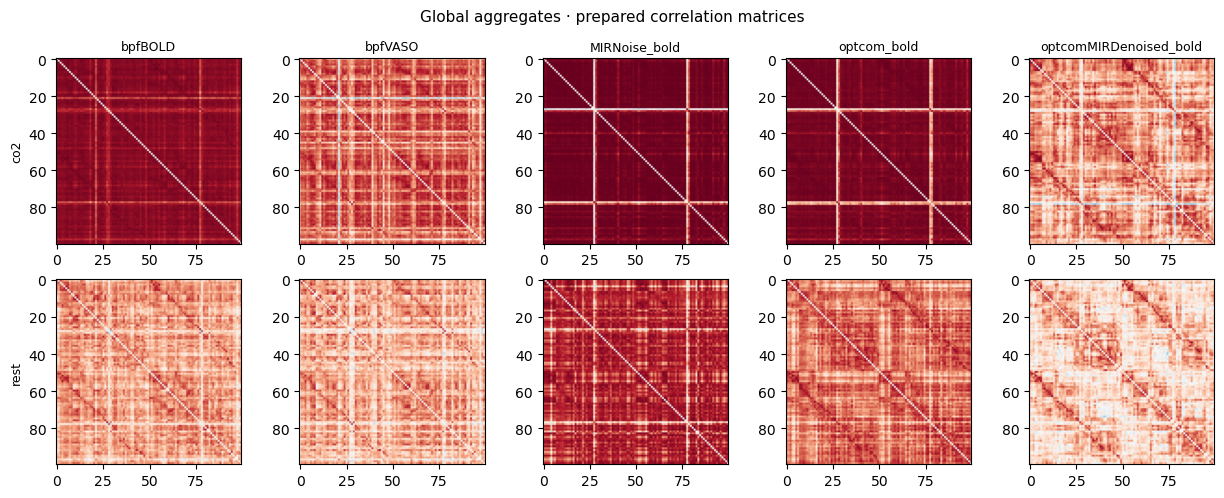

In [2]:
fig, _ = plot_results_grid(
    globals_by_cp,
    plot_correlation_matrix,
    row_keys=list(CONTRASTS),
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(2.5, 2.5),
    suptitle='Global aggregates · prepared correlation matrices',
    colorbar=False,
    vmax=1.0,
)
plt.show()

### Per-patient sample, by band

The global aggregates above pool across subjects, so they hide inter-subject heterogeneity. As a sanity check we plot a small per-patient slice: $2$ subjects (`sub-00246757`, `sub-VA9757`) $\times\ 2$ contrasts (`co2`, `rest`) $\times\ 5$ processing variants, **separately for each of the three slow bands** $s4$, $s5$, $s^\ast$.

Bands `s4`, `s5`, `sstar` are **slow intrinsic mode functions (IMFs)** obtained by Empirical Mode Decomposition (EMD) of each ROI's BOLD/VASO time series. Lower-index IMFs carry higher-frequency content; in this batch typically

$$
\text{freq}(s4) \;>\; \text{freq}(s5) \;>\; \text{freq}(s^\ast),
$$

i.e. `sstar` is the slowest. The exact passband per band is dataset-specific and is reported in the collaborator manifest — we do not assume a fixed Hz mapping here. We render one figure per band so the $4 \times 5$ panel grids stay readable.

In [3]:
patient_entries = discover_april(APRIL_ROOT, levels=['patient'])

samples_corr = {band: {} for band in SAMPLE_BANDS}
samples_weights = {band: {} for band in SAMPLE_BANDS}

for entry in patient_entries:
    if entry.subject not in SAMPLE_SUBJECTS or entry.band not in SAMPLE_BANDS:
        continue
    key = ((entry.subject, entry.contrast), entry.processing)
    matrix = prepare_correlation_matrix(load_entry(entry))
    samples_corr[entry.band][key] = matrix
    samples_weights[entry.band][key] = weight_distribution_analysis(matrix)

sample_row_keys = [
    (sub, contrast) for sub in SAMPLE_SUBJECTS for contrast in CONTRASTS
]
sample_row_labels = [
    f"{sub.replace('sub-', '')}\n{contrast}" for sub, contrast in sample_row_keys
]

expected_per_band = len(sample_row_keys) * len(PROCESSING_VARIANTS)
totals = {band: len(samples_corr[band]) for band in SAMPLE_BANDS}
print(
    f"Per-band matrix counts: {totals} "
    f"(expected {expected_per_band} each) "
    f"loaded from {APRIL_ROOT.resolve()}"
)

Per-band matrix counts: {'s4': 20, 's5': 20, 'sstar': 20} (expected 20 each) loaded from /home/opisthofulax/Documents/research+/brain_network/multifun-brain/data/correlation_mat_april_data


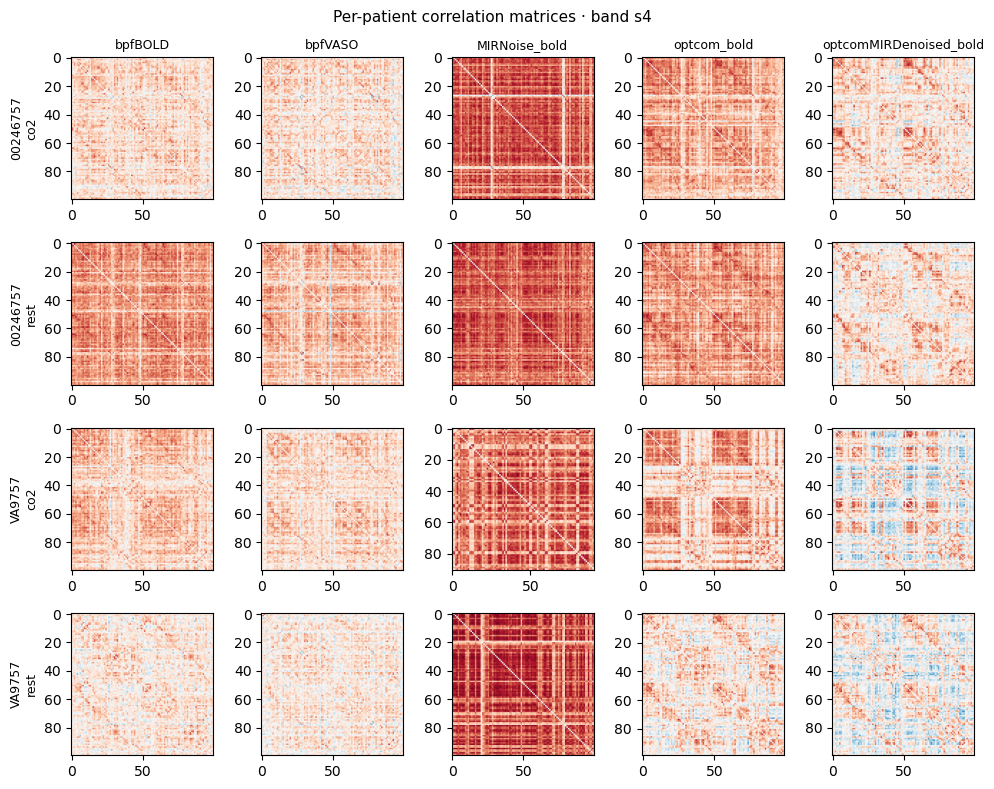

In [4]:
band = 's4'
fig, _ = plot_results_grid(
    samples_corr[band],
    plot_correlation_matrix,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.0, 2.0),
    suptitle=f'Per-patient correlation matrices · band {band}',
    colorbar=False,
    vmax=1.0,
)
plt.show()

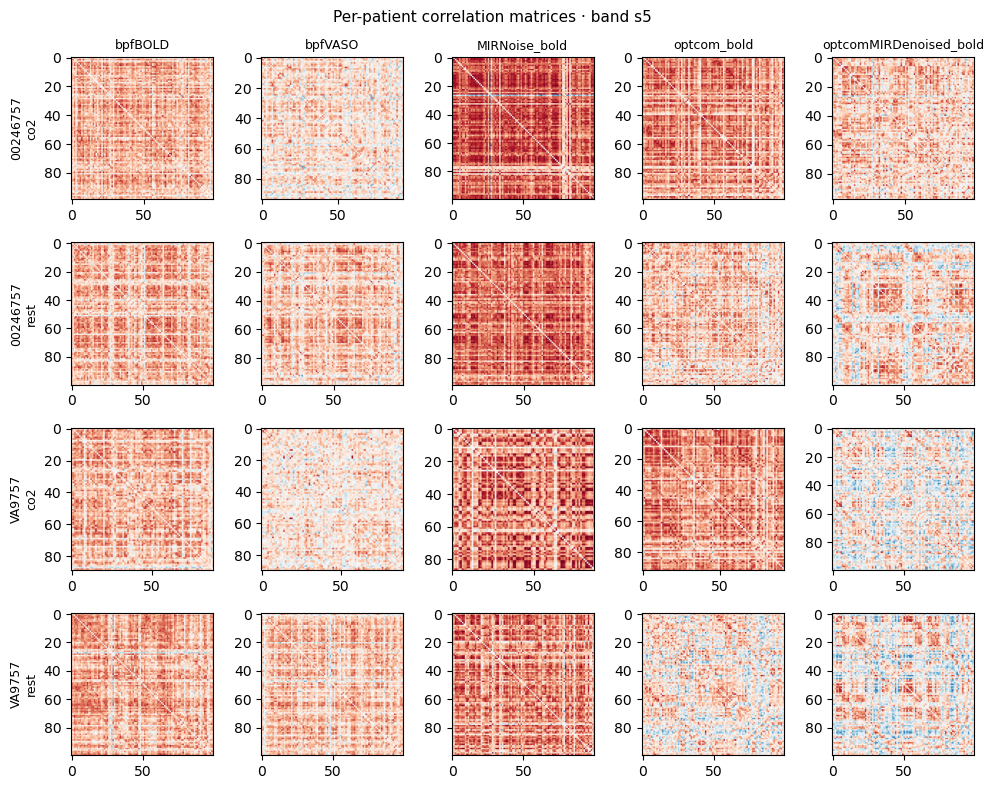

In [5]:
band = 's5'
fig, _ = plot_results_grid(
    samples_corr[band],
    plot_correlation_matrix,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.0, 2.0),
    suptitle=f'Per-patient correlation matrices · band {band}',
    colorbar=False,
    vmax=1.0,
)
plt.show()

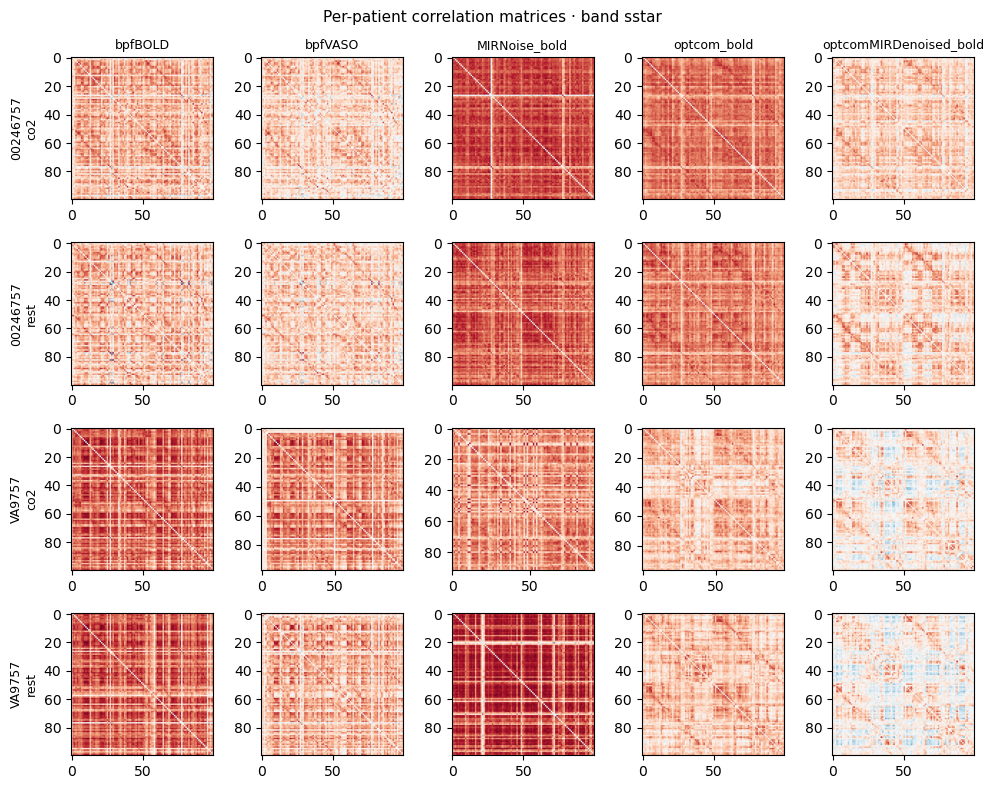

In [6]:
band = 'sstar'
fig, _ = plot_results_grid(
    samples_corr[band],
    plot_correlation_matrix,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.0, 2.0),
    suptitle=f'Per-patient correlation matrices · band {band}',
    colorbar=False,
    vmax=1.0,
)
plt.show()

## 2 · Edge-weight distributions

Before any thresholding, it is useful to inspect the marginal distribution of off-diagonal entries

$$
\mathcal{P}(c) \;=\; \frac{1}{N(N-1)} \sum_{i \neq j} \delta\bigl(c - C_{ij}\bigr).
$$

For a signed correlation matrix $\mathcal{P}(c)$ is supported on $[-1, 1]$ and is typically peaked near zero with shoulders on both sides — a "bimodal-ish" shape that reflects coherent functional sub-networks (positive shoulder) and anticorrelated network pairs (negative shoulder, e.g. task-positive vs default-mode).

Two coarse first signals are worth flagging at this stage:

- a **mean shift** between `co2` and `rest`, $\langle C \rangle_{\text{co2}} - \langle C \rangle_{\text{rest}}$, would indicate a global vasoreactive baseline change;
- a **skew change** in either tail (positive or negative) localises the contrast effect to specific network polarities.

If MP shrinkage were applied (it is not in this notebook), it would compress the bulk of $\mathcal{P}(c)$ toward $0$ — coefficients consistent with the noise null are pulled into the centre — and what remains above roughly $|C| \gtrsim 1 - \sqrt{\gamma} \approx 0.5$ for $\gamma \sim 0.2$ would be the signal-dominated tails. Here we leave the raw distribution intact and let the percolation scan in section 3 act as the noise discriminator.

Histograms below are split: **positive** weights in blue, **negative** weights in red, dashed vertical line at $c = 0$. Counts in legends are the number of edges per sign.

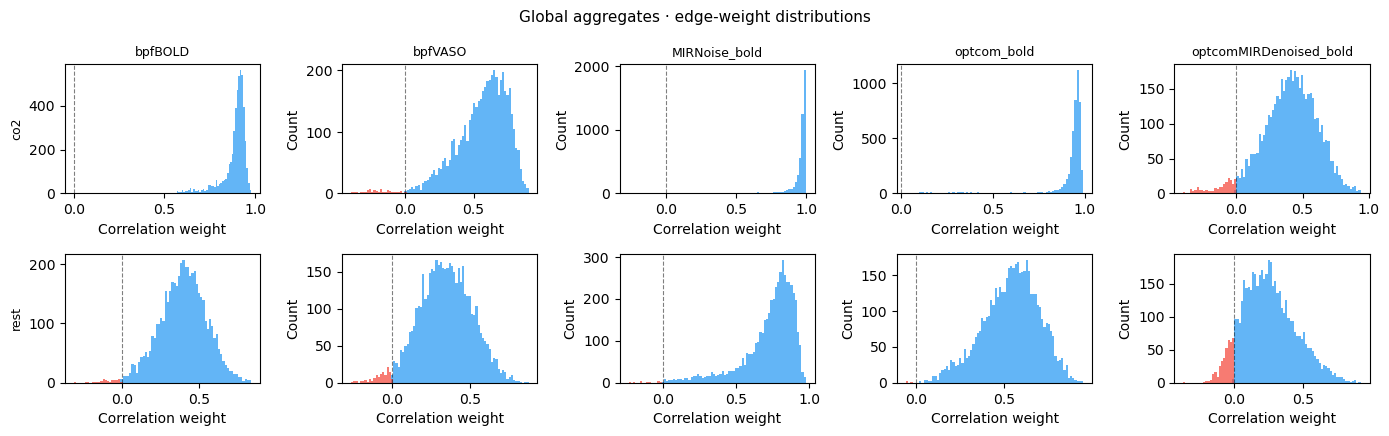

In [7]:
fig, _ = plot_results_grid(
    globals_by_cp,
    plot_weight_distribution,
    row_keys=list(CONTRASTS),
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(2.8, 2.2),
    suptitle='Global aggregates · edge-weight distributions',
    legend=False,
    title=None,
)
plt.show()

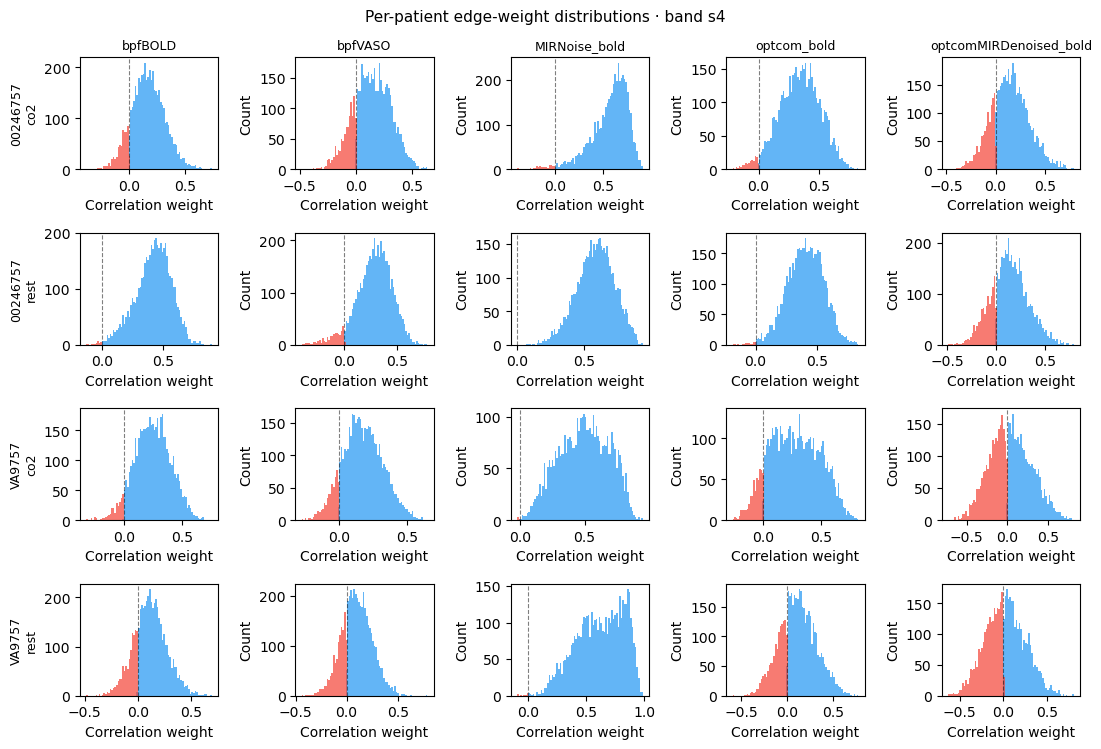

In [8]:
band = 's4'
fig, _ = plot_results_grid(
    samples_weights[band],
    plot_weight_distribution,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient edge-weight distributions · band {band}',
    legend=False,
    title=None,
)
plt.show()

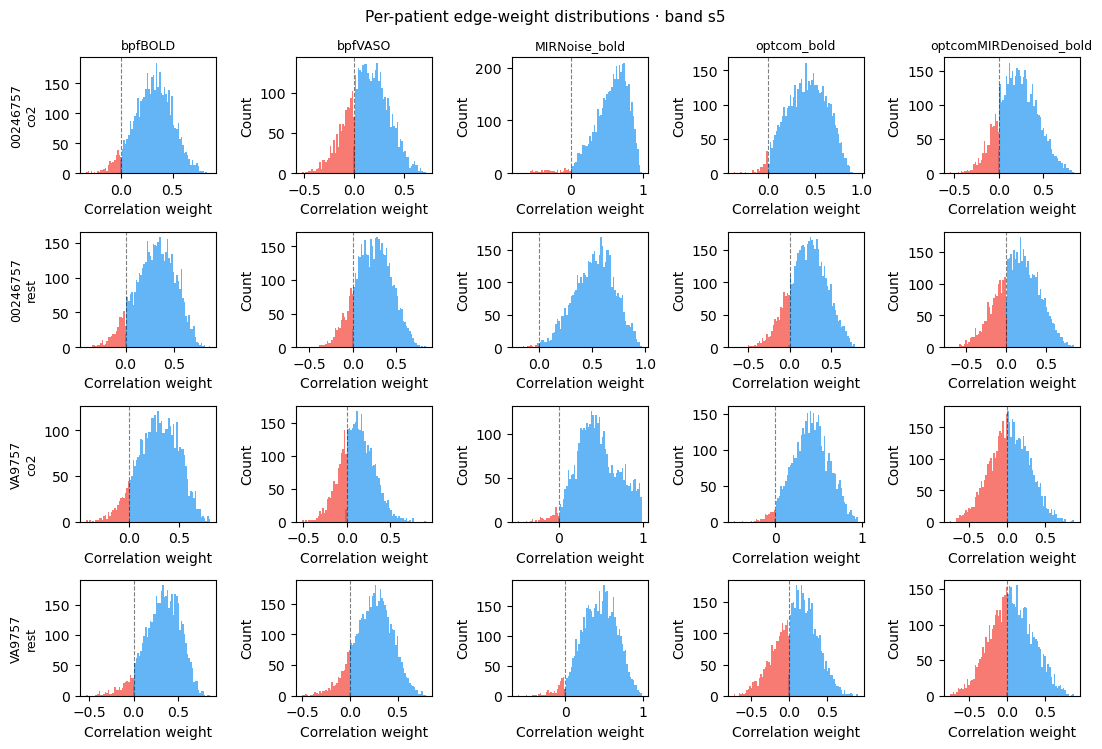

In [9]:
band = 's5'
fig, _ = plot_results_grid(
    samples_weights[band],
    plot_weight_distribution,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient edge-weight distributions · band {band}',
    legend=False,
    title=None,
)
plt.show()

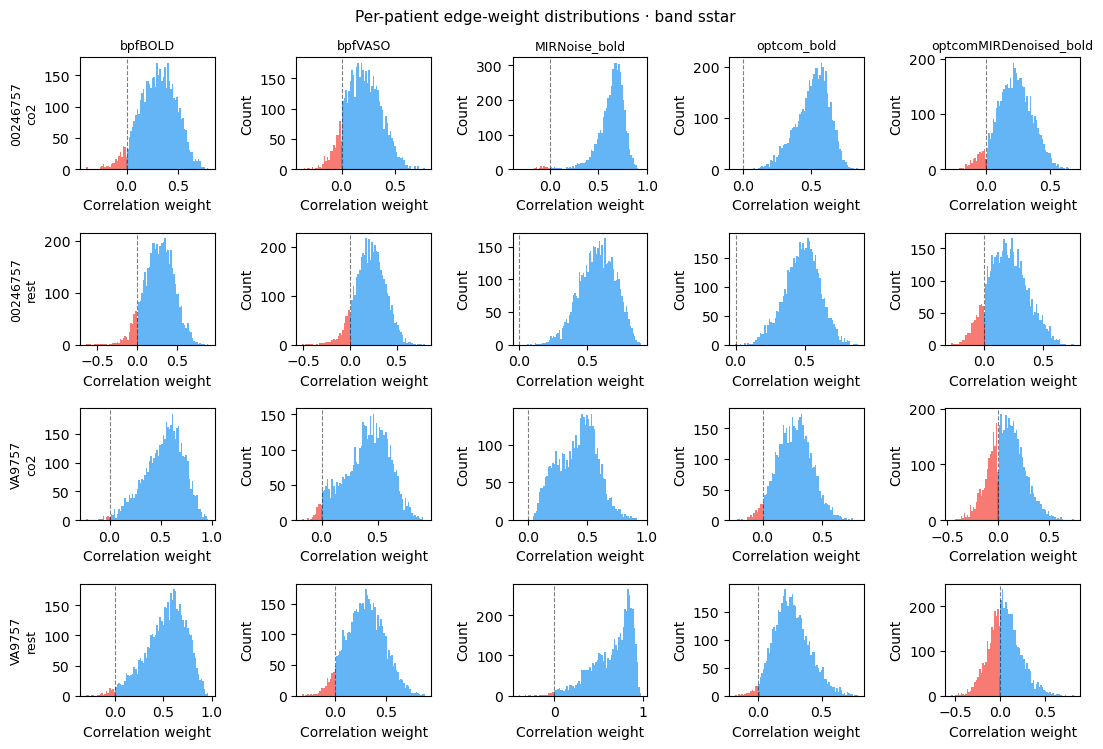

In [10]:
band = 'sstar'
fig, _ = plot_results_grid(
    samples_weights[band],
    plot_weight_distribution,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient edge-weight distributions · band {band}',
    legend=False,
    title=None,
)
plt.show()

## 3 · Percolation curves — $P_\infty$ and $E_\infty$ vs threshold

We now probe the **topology** of each matrix as a function of an edge-weight threshold. Working with the magnitude $|C|$ so we can treat sign separately, for $\theta \in [0,\, \max_{i \neq j} |C_{ij}|]$ define the thresholded graph

$$
G(\theta) \;=\; \bigl\{(i, j) \,:\, |C_{ij}| \,\geq\, \theta \bigr\},
$$

and from it the two order parameters scanned by `processing.percolation.percolation_curve`:

$$
P_\infty(\theta) \;=\; \frac{\bigl|\text{largest connected component of } G(\theta)\bigr|}{N},
\qquad
E_\infty(\theta) \;=\; \frac{\bigl|E\bigl(G(\theta)\bigr)\bigr|}{N(N-1)/2}.
$$

$P_\infty$ is the **fraction of nodes** in the largest connected component; $E_\infty$ is the **fraction of surviving edges** at threshold $\theta$, normalised by the maximum possible $\binom{N}{2}$. Both lie in $[0, 1]$ and decrease (weakly) monotonically with $\theta$.

Interpretation:

- A **single sharp drop** in $P_\infty(\theta)$ near a critical $\theta_c$ is the signature of a random-graph–like Erdős–Rényi percolation transition — no privileged sub-structure.
- A **staircase** in $P_\infty(\theta)$ — multiple plateaus separated by drops — indicates **functional submodules detaching at different correlation strengths**, i.e. genuine modular structure worth exposing with LRG diffusion.
- The **shape of $E_\infty(\theta)$** complements $P_\infty$: $P_\infty$ can stay near $1$ even when most edges are gone (as long as one spanning tree survives), whereas $E_\infty$ tracks the actual edge density. A regime where $P_\infty \approx 1$ and $E_\infty \ll 1$ is exactly a **connected sparse backbone** — the regime targeted by the percolation-threshold backbone in section 3 of the pipeline.

The companion critical threshold $\theta^\ast = \min_i \max_j |C_{ij}|$ (returned by `percolation_threshold`) is the largest $\theta$ at which every node still has at least one incident edge — the natural cutoff for a **connected backbone** that loses no nodes. The per-patient panels are split by band (one figure per $s4$, $s5$, $s^\ast$) to keep the $y$-axis dynamic range readable.

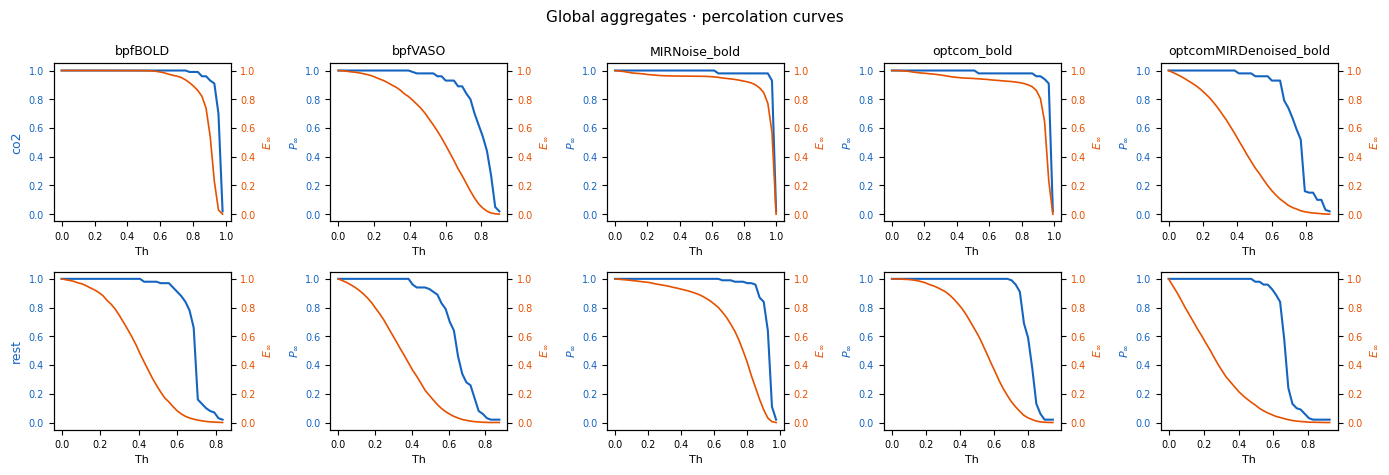

In [11]:
fig, _ = plot_results_grid(
    globals_by_cp,
    plot_percolation_curve,
    row_keys=list(CONTRASTS),
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(2.8, 2.4),
    suptitle='Global aggregates · percolation curves',
    n_thresholds=40,
)
plt.show()

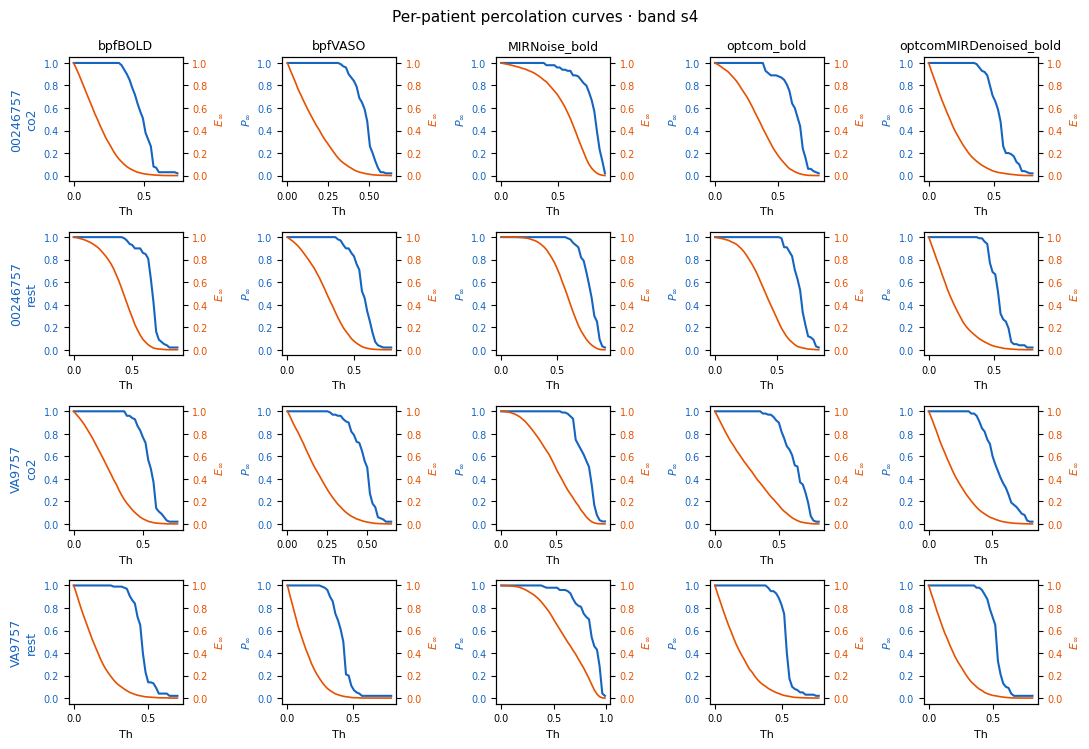

In [12]:
band = 's4'
fig, _ = plot_results_grid(
    samples_corr[band],
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation curves · band {band}',
    n_thresholds=40,
)
plt.show()

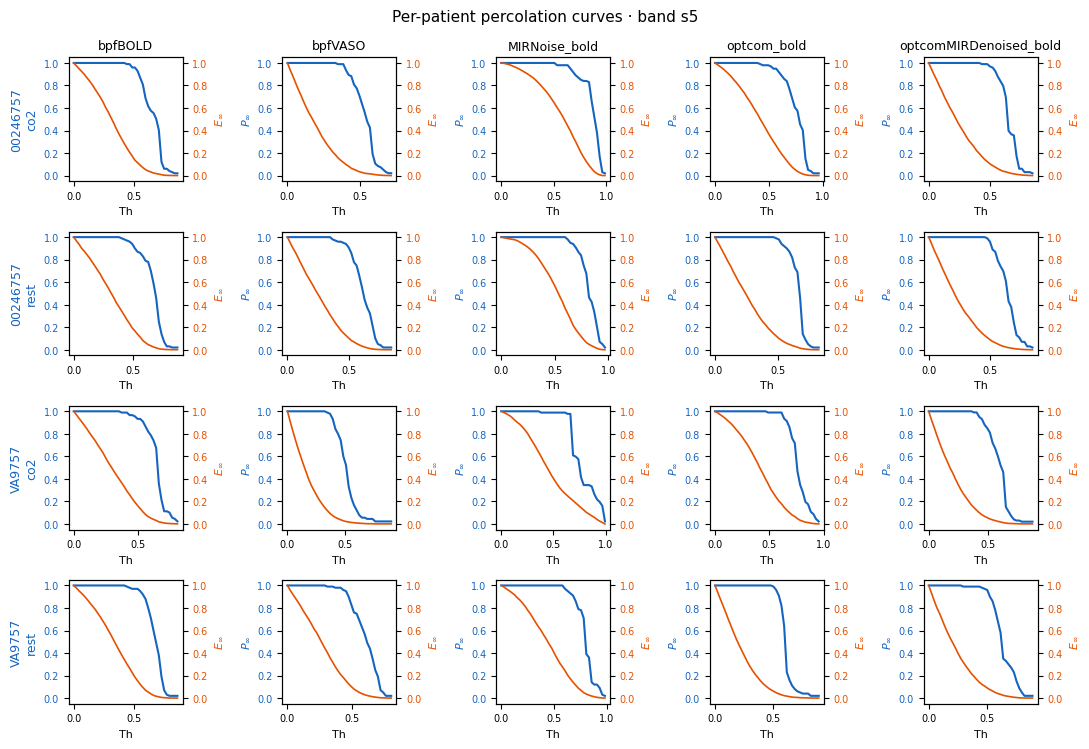

In [13]:
band = 's5'
fig, _ = plot_results_grid(
    samples_corr[band],
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation curves · band {band}',
    n_thresholds=40,
)
plt.show()

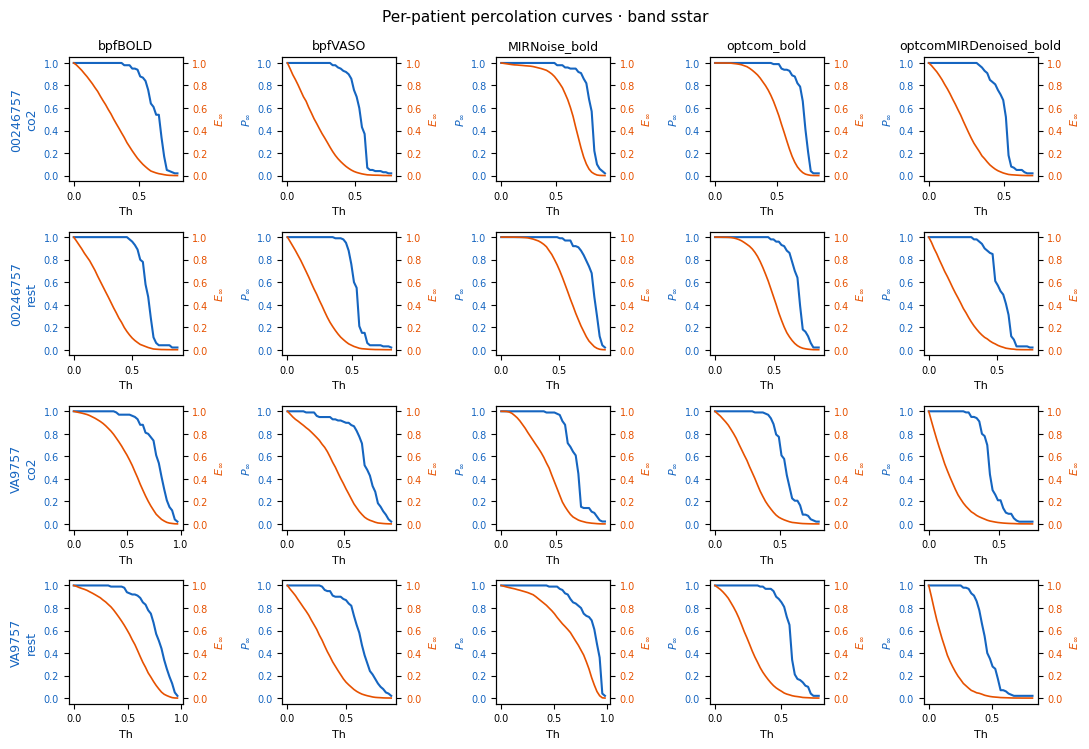

In [14]:
band = 'sstar'
fig, _ = plot_results_grid(
    samples_corr[band],
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation curves · band {band}',
    n_thresholds=40,
)
plt.show()

## 4 · Positive-only thresholding — does the structure live in $C_{ij} \geq 0$?

In the percolation scan above, we thresholded on $|C_{ij}|$, which collapses anti-correlations and positive correlations into a single edge-weight axis. In resting-state fMRI the negative tail of $C$ is largely **noise** (motion residuals, global-signal regression artefacts, opposite-phase haemodynamic responses), so treating it as additional signal can flatten genuine modular structure.

Re-do the scan on **positive-only** edges: set $C_{ij} \mapsto \max(C_{ij}, 0)$ before thresholding. Formally,

$$
G^+(\theta) \;=\; \bigl\{(i, j) \,:\, C_{ij} \,\geq\, \theta \bigr\}, \qquad \theta \in [0, \max_{i \neq j} C_{ij}].
$$

If a staircase appears here that was hidden under $|C|$, the modular structure is **carried by the positive correlations** and the negative tail was washing it out.

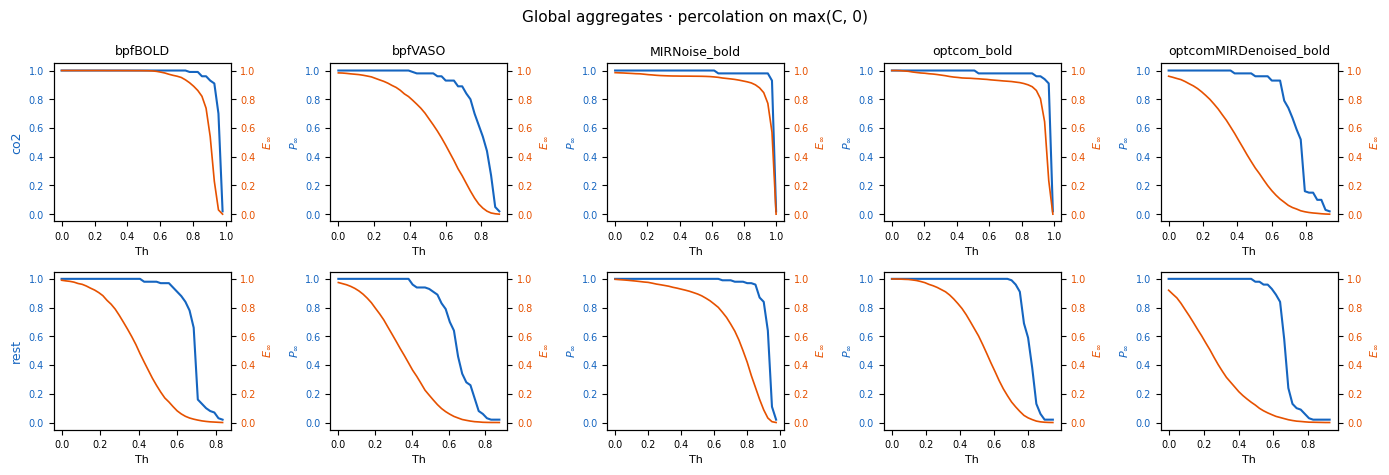

In [15]:
globals_pos = {
    k: np.clip(r.corr_prepared, 0.0, 1.0) for k, r in globals_by_cp.items()
}
fig, _ = plot_results_grid(
    globals_pos,
    plot_percolation_curve,
    row_keys=list(CONTRASTS),
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(2.8, 2.4),
    suptitle='Global aggregates · percolation on max(C, 0)',
    n_thresholds=40,
)
plt.show()

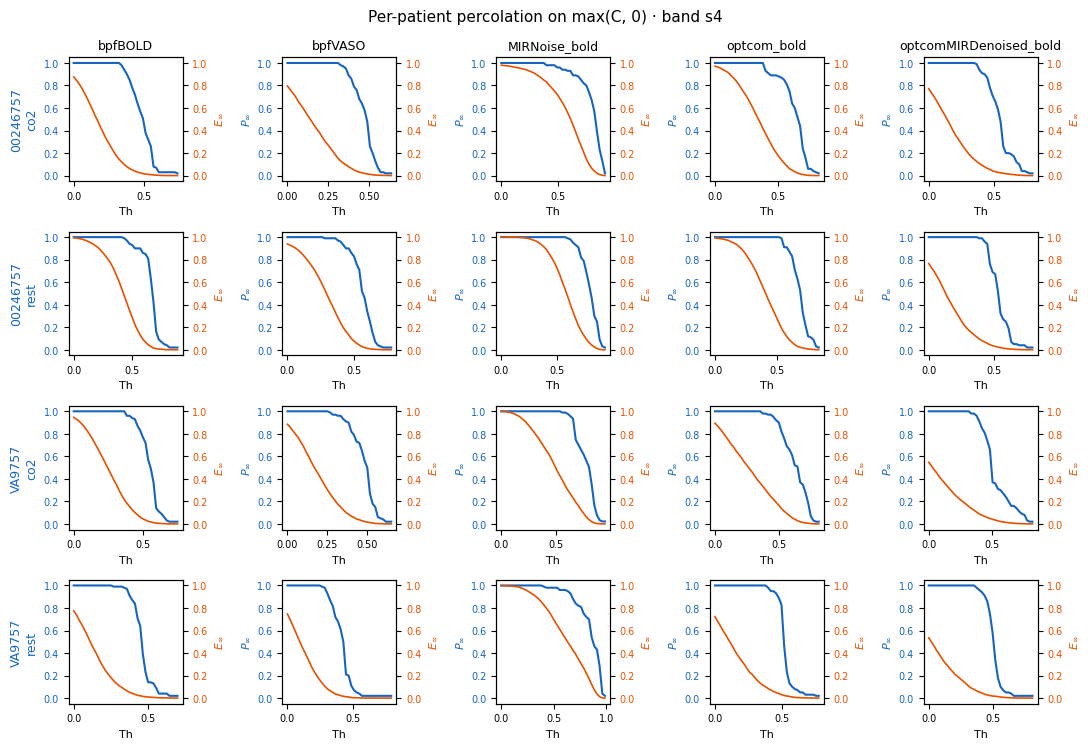

In [16]:
band = 's4'
samples_pos = {
    k: np.clip(v, 0.0, 1.0) for k, v in samples_corr[band].items()
}
fig, _ = plot_results_grid(
    samples_pos,
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation on max(C, 0) · band {band}',
    n_thresholds=40,
)
plt.show()

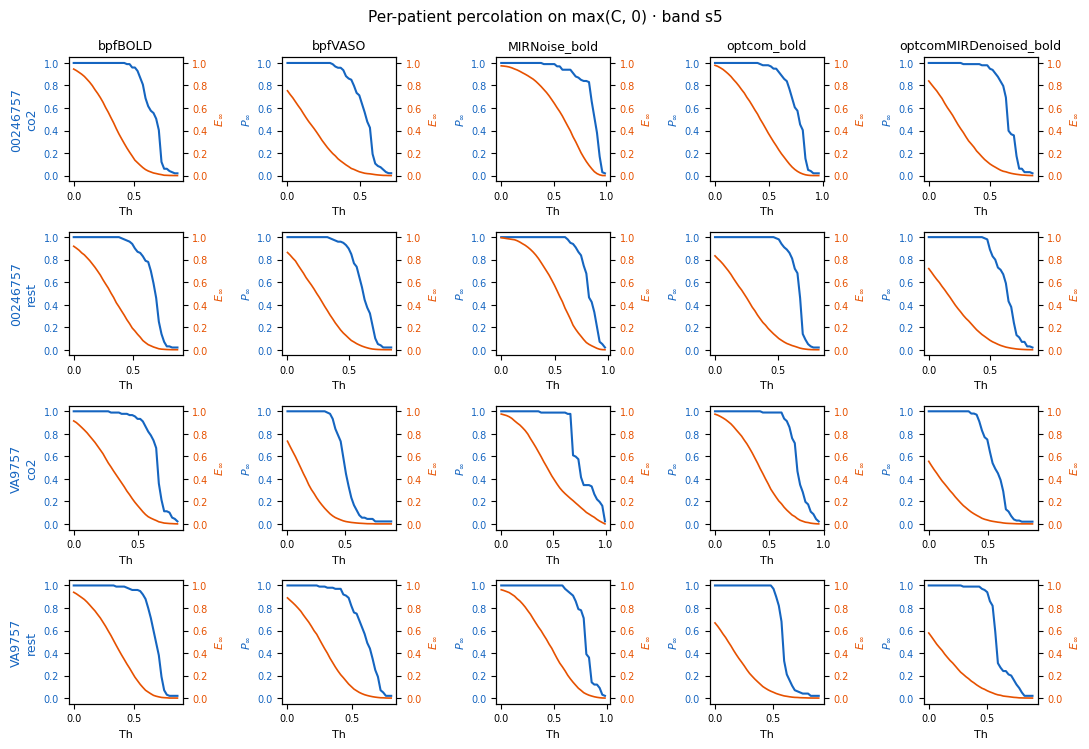

In [17]:
band = 's5'
samples_pos = {
    k: np.clip(v, 0.0, 1.0) for k, v in samples_corr[band].items()
}
fig, _ = plot_results_grid(
    samples_pos,
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation on max(C, 0) · band {band}',
    n_thresholds=40,
)
plt.show()

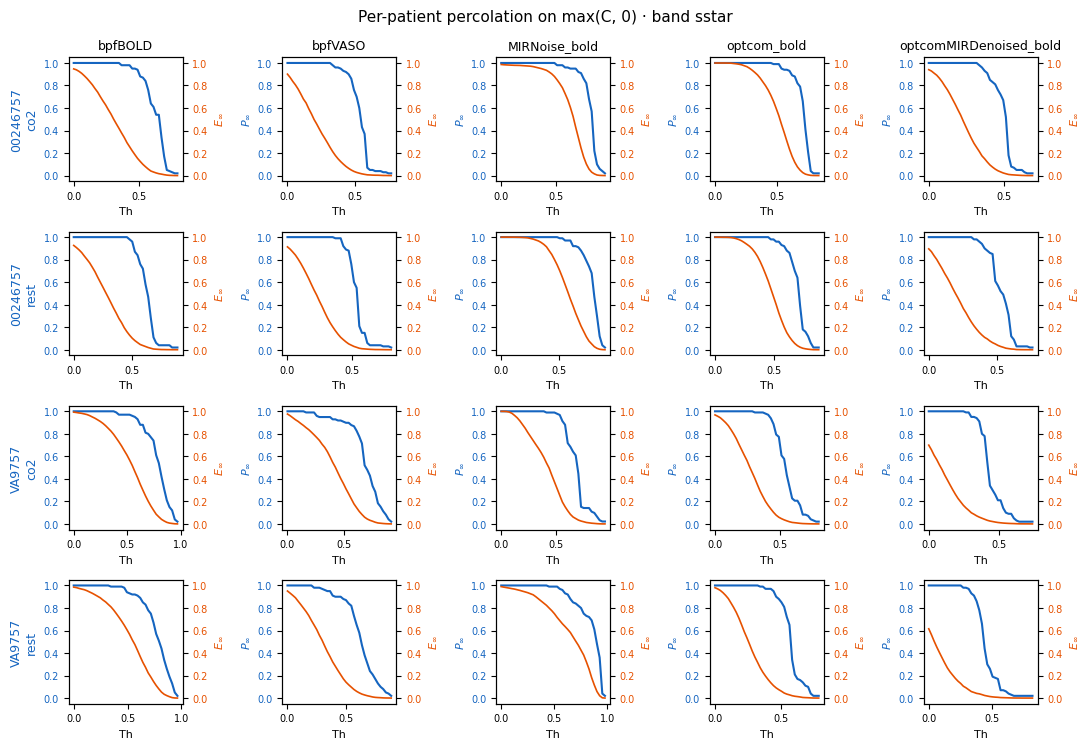

In [18]:
band = 'sstar'
samples_pos = {
    k: np.clip(v, 0.0, 1.0) for k, v in samples_corr[band].items()
}
fig, _ = plot_results_grid(
    samples_pos,
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation on max(C, 0) · band {band}',
    n_thresholds=40,
)
plt.show()

## 5 · MP-denoised percolation — clean the signed matrix first

The Marchenko–Pastur prediction $\lambda_\pm = \sigma^2 (1 \pm \sqrt\gamma)^2$ applies to the **raw signed sample correlation matrix** $C = \tfrac{1}{T} X X^\top$ of i.i.d.-Gaussian standardised time series — *not* to $|C|$, $\max(C, 0)$, or any backbone derivative. So the conceptually clean order is

$$
C \;\xrightarrow{\text{MP shrink}}\; \widetilde{C} \;\xrightarrow{\text{filter / threshold}}\; G(\theta).
$$

`marchenko_pastur_denoise` diagonalises $C$, clips eigenvalues lying inside the MP support $[\lambda_-, \lambda_+]$ to the support boundary (so noise eigenmodes are flattened but not removed), and reconstructs $\widetilde{C}$ in the original eigenbasis. We then run the same $|·|$-percolation scan on $\widetilde{C}$. Each matrix is denoised with its own $\gamma = N / T$ — see `GAMMA_BY_PROCESSING` above.

If the MP-denoised version shows a staircase that the raw version didn't, the modular structure was real but buried under the noise bulk.

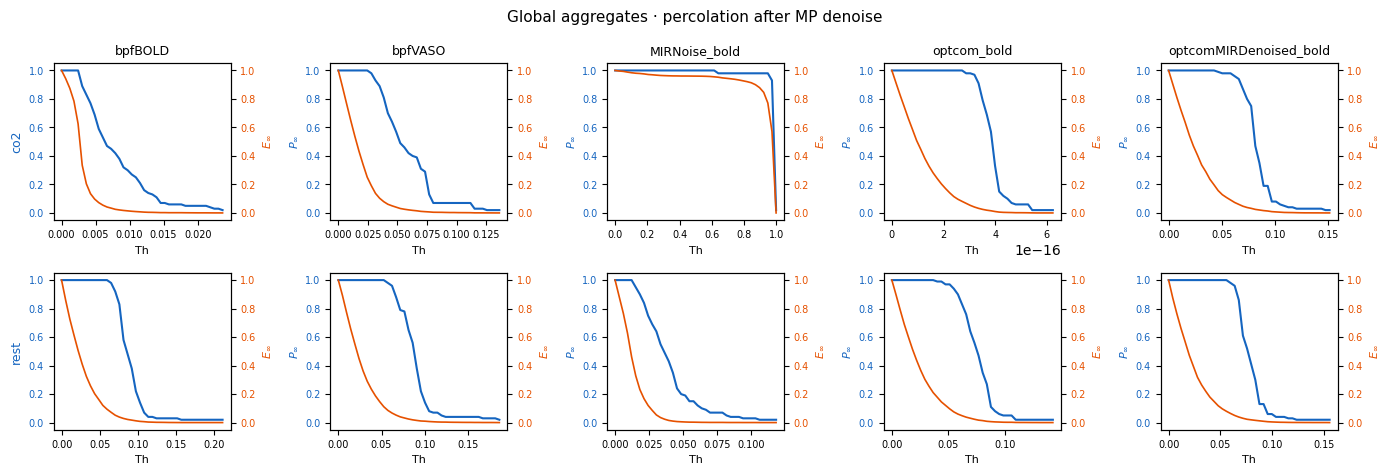

In [19]:
globals_mp = {}
for (contrast, processing), r in globals_by_cp.items():
    g = GAMMA_BY_PROCESSING[processing]
    globals_mp[(contrast, processing)] = marchenko_pastur_denoise(
        r.corr_prepared, gamma=g
    )

fig, _ = plot_results_grid(
    globals_mp,
    plot_percolation_curve,
    row_keys=list(CONTRASTS),
    col_keys=list(PROCESSING_VARIANTS),
    figsize_per_cell=(2.8, 2.4),
    suptitle=r'Global aggregates · percolation after MP denoise',
    n_thresholds=40,
)
plt.show()

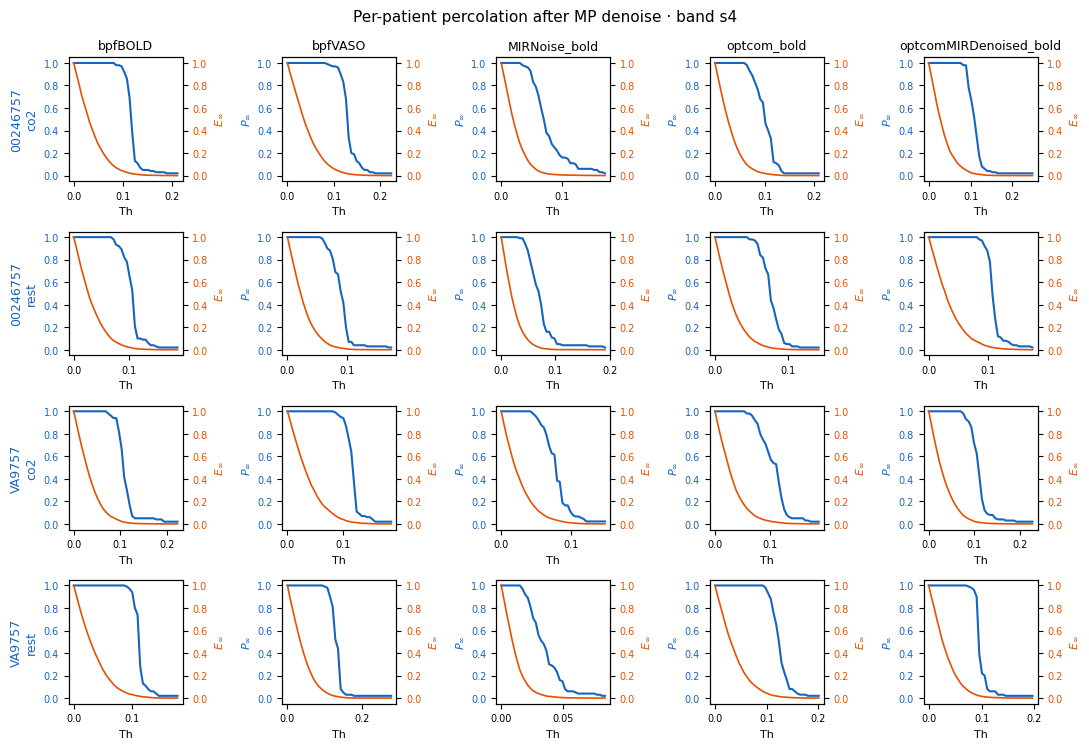

In [20]:
band = 's4'
samples_mp = {}
for key, matrix in samples_corr[band].items():
    processing = key[1]
    g = GAMMA_BY_PROCESSING[processing]
    samples_mp[key] = marchenko_pastur_denoise(matrix, gamma=g)

fig, _ = plot_results_grid(
    samples_mp,
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation after MP denoise · band {band}',
    n_thresholds=40,
)
plt.show()

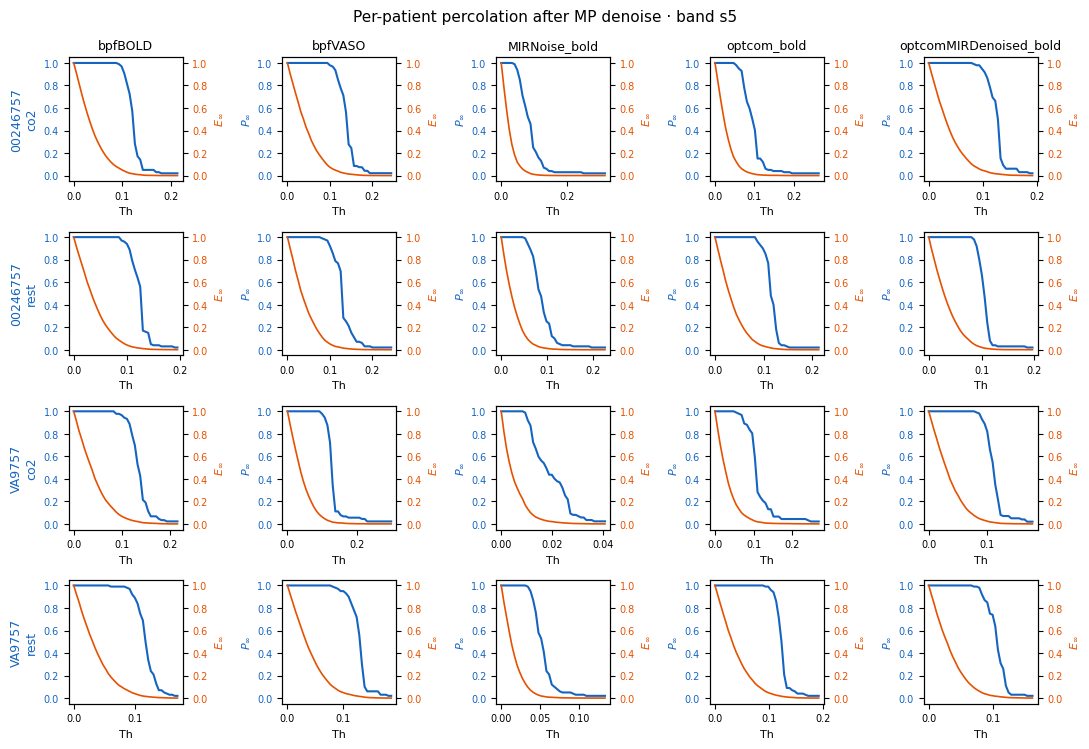

In [21]:
band = 's5'
samples_mp = {}
for key, matrix in samples_corr[band].items():
    processing = key[1]
    g = GAMMA_BY_PROCESSING[processing]
    samples_mp[key] = marchenko_pastur_denoise(matrix, gamma=g)

fig, _ = plot_results_grid(
    samples_mp,
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation after MP denoise · band {band}',
    n_thresholds=40,
)
plt.show()

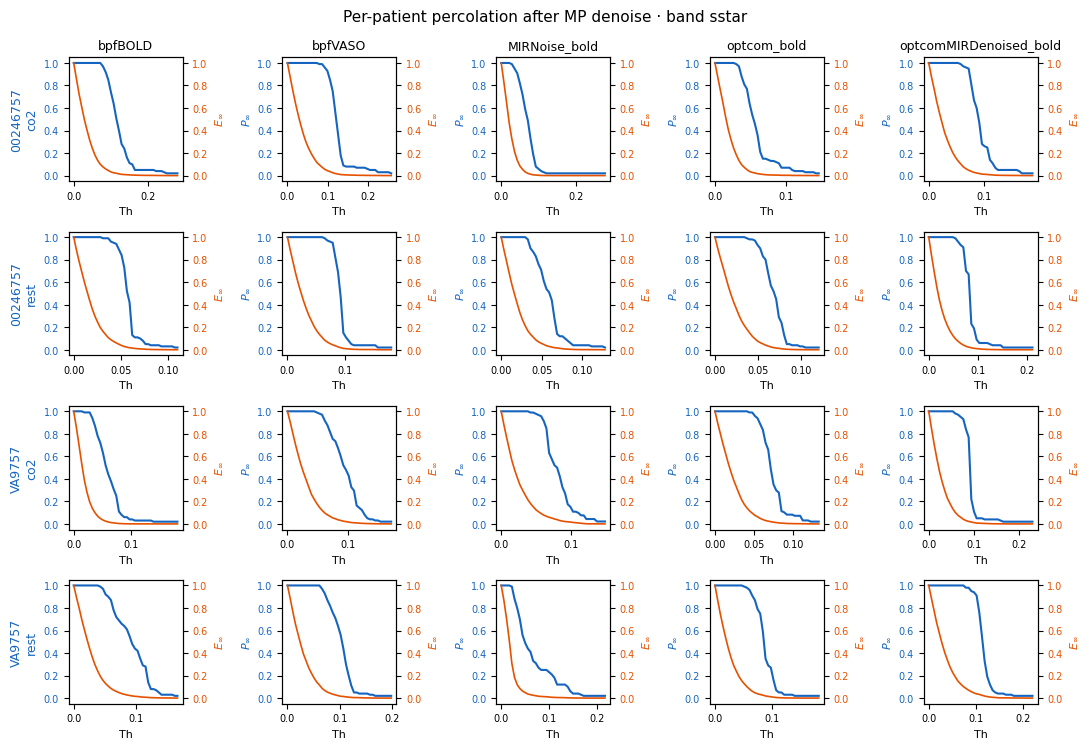

In [22]:
band = 'sstar'
samples_mp = {}
for key, matrix in samples_corr[band].items():
    processing = key[1]
    g = GAMMA_BY_PROCESSING[processing]
    samples_mp[key] = marchenko_pastur_denoise(matrix, gamma=g)

fig, _ = plot_results_grid(
    samples_mp,
    plot_percolation_curve,
    row_keys=sample_row_keys,
    col_keys=list(PROCESSING_VARIANTS),
    row_labels=sample_row_labels,
    figsize_per_cell=(2.2, 1.9),
    suptitle=f'Per-patient percolation after MP denoise · band {band}',
    n_thresholds=40,
)
plt.show()

## 6 · What kind of networks are we looking at?

At this point in the pipeline, each panel above is a **dense, weighted, signed graph on $N \approx 100$ Schaefer ROIs**. No thresholding has been applied to the raw matrices in §1: every off-diagonal entry $C_{ij}$ is an edge weight in $[-1, 1]$, and the only operations performed there are dead-region removal, symmetrisation, clipping, and zero-diagonal — i.e. structural hygiene, no information removed beyond non-existent ROIs.

Consequences for what we can and cannot say from these figures:

- **Standard unsigned graph metrics don't apply yet.** Clustering coefficient, modularity $Q$, betweenness, etc. all assume non-negative weights. On signed $C$ the appropriate substitutes are the *signed* Laplacian $L_{\pm} = |D| - A$, the frustration index, and the balance ratio (see `analysis.descriptive.signed`). These are run in section 1 of the pipeline.
- **The §3 percolation scan on $|C|$ produces a single sharp drop**, not a staircase — consistent with random-graph-like topology *or* with modular structure buried under the noise bulk. §4 (positive-only) and §5 (MP-denoised) above are the two cleanest decompositions of which.
- **If §4 shows a staircase but §3 didn't**, the modular structure lives in the positive correlations and the negative tail (noise / artifacts) was washing it out under $|C|$.
- **If §5 shows a staircase but §3 didn't**, the modular structure is real but lives below the MP noise floor — only emerges once the bulk eigenmodes are flattened.
- **If neither §4 nor §5 produces a staircase**, the conclusion stands: at this resolution the matrices behave like a single homogeneously well-connected core, and any modular hierarchy will have to come from the **section-2 backbone step** (disparity / LANS / MP-validated filter) rather than from raw thresholding.
- **Per-band heterogeneity** across $s4 / s5 / s^\ast$ remains visible across §3–§5; whichever variant exposes structure should also expose its frequency dependence.

**Next.** Notebooks `02_band_comparison`, `03_patient_variability`, `04_contrast_comparison` consume the **sparsified backbones** produced by `processing.backbone` and feed them to the LRG stack to produce multi-scale partitions and ARI comparisons across contrasts/bands/subjects.